## (Optional) Initialize state from environment variable, for command line execution

If run as a standalone Notebook, set the state directly in the first cell.

In [1]:
import os
# Read fitness data from CSV files
main_dir = os.getenv("MAIN_DIR", "fitnesses")
# Save outputs here
output_dir = os.getenv("OUTPUT_DIR", "filtering")
# Copy the output models that survive the filtering here
output_models_dir = os.getenv("FILTERED_OUTPUT_DIR", "filtered")
# Original directory for the boolean models
mutated_boolean_models_dir = os.getenv("MUTATED_BOOLEAN_MODELS_DIR", "pool")


os.makedirs(output_dir, exist_ok=True)
os.makedirs(output_models_dir, exist_ok=True)
# Filtering threshold for sensitivity
MEAN_THRESHOLD = os.getenv("MEAN_THRESHOLD", 0.0)
MEAN_THRESHOLD = float(MEAN_THRESHOLD)

ABS_STD_THRESHOLD = os.getenv("ABS_STD_THRESHOLD", 30.0)
ABS_STD_THRESHOLD = float(ABS_STD_THRESHOLD)
NORM_STD_THRESHOLD = os.getenv("NORM_STD_THRESHOLD", 0.2)
NORM_STD_THRESHOLD = float(NORM_STD_THRESHOLD)


In [2]:
print(f"Running from directory:", os.getcwd())
print("Running with main dir: ", main_dir)
print("Output dir: ", output_dir)
print("Files found in main dir: ", os.listdir(main_dir))

Running from directory: /home/marco/Projects/sensitivity_analysis
Running with main dir:  fitnesses
Output dir:  filtering
Files found in main dir:  ['144_fitness_step.csv', '1034_fitness_step.csv', '1623_fitness_step.csv', '862_fitness_step.csv', '1139_fitness_step.csv', '1007_fitness_step.csv', '1010_fitness_step.csv', '70_fitness_step.csv', '464_fitness_step.csv', '1525_fitness_step.csv', '504_fitness_step.csv', '1263_fitness_step.csv', '561_fitness_step.csv', '1980_fitness_step.csv', '1888_fitness_step.csv', '723_fitness_step.csv', '1666_fitness_step.csv', '1458_fitness_step.csv', '2000_fitness_step.csv', '165_fitness_step.csv', '712_fitness_step.csv', '1367_fitness_step.csv', '602_fitness_step.csv', '1152_fitness_step.csv', '883_fitness_step.csv', '1813_fitness_step.csv', '836_fitness_step.csv', '2072_fitness_step.csv', '973_fitness_step.csv', '280_fitness_step.csv', '2049_fitness_step.csv', '967_fitness_step.csv', '770_fitness_step.csv', '1052_fitness_step.csv', '1846_fitness_ste

# Load Dataset

Dataset of simulations is readed from file system and inserted into an np array.

In [3]:
import numpy as np
import os
import csv
import matplotlib.pyplot as plt

dataset = []
i=0
broken_reads = 0
while True:
    file_name = os.path.join(main_dir, f"{i}_fitness_step.csv")
    if not os.path.exists(file_name):
        print("No files to load.")
        break
    step = 1
    while os.path.exists(os.path.join(main_dir, f"{i}_fitness_step_{step}.csv")):
        file_name = os.path.join(main_dir, f"{i}_fitness_step_{step}.csv")
        step += 1
    context_ds = []
    with open(file_name, 'r') as csvfile:
        reader = csv.reader(csvfile)
        next(reader, None)  # Skip the header row
        for row in reader:
            if len(row) > 0:
                try:
                    context_ds.append([float(x) for x in row])
                except ValueError:
                    #print(f"Warning: Non-numeric data found in {file_name}, skipping row: {row}")
                    broken_reads += 1
                    context_ds.append([np.nan for x in row])
    if len(context_ds) == 0:
        print(f"Warning: {file_name} is empty, skipping.")
        i += 1
        continue
    dataset.append(context_ds)
    i += 1

dataset = np.array(dataset)

function_names = ["AliveCellsFitness","CircularFitness","CircularFitness_WT_DISTRIBUTION","SquaredFitness","SquaredFitness_WT_DISTRIBUTION","CircularFitness_2","CircularFitness_2_WT_DISTRIBUTION","SquaredFitness_2","SquaredFitness_2_WT_DISTRIBUTION"]


print(f"Dataset loaded: {dataset.shape}")
print(f"Function names: {function_names}")
print(f"Broken reads: {broken_reads}")

No files to load.
Dataset loaded: (2122, 215, 9)
Function names: ['AliveCellsFitness', 'CircularFitness', 'CircularFitness_WT_DISTRIBUTION', 'SquaredFitness', 'SquaredFitness_WT_DISTRIBUTION', 'CircularFitness_2', 'CircularFitness_2_WT_DISTRIBUTION', 'SquaredFitness_2', 'SquaredFitness_2_WT_DISTRIBUTION']
Broken reads: 0


# Clean dataset

Some linear fitness function might contain NaNs, which will break following analysis.
NaNs are replaced with column average: this way they don't artificially improve the measured standard deviation.

In [4]:
number_of_nans = np.sum(np.isnan(dataset))
# Replace NaNs with the average of the respective function across all contexts
for i in range(dataset.shape[0]):
    for j in range(dataset.shape[2]):
        avg = np.nanmean(dataset[i,:,j])
        if (np.isnan(avg)):
            avg = 0.0
        dataset[i,np.isnan(dataset[i,:,j]),j] = avg

print(f"Dataset after NaN replacement: {dataset.shape}")

Dataset after NaN replacement: (2122, 215, 9)


/tmp/ipykernel_10196/2432973720.py:5: RuntimeWarning: Mean of empty slice
  avg = np.nanmean(dataset[i,:,j])


## Early visualization: PCA to visualize models

### First analysis plot considers the entire dataset: 
* Different fitness functions over same models seen as separate models.
* It's possible to identify 8 clear tracks: most likely, they show 8 of the 9 fitness functions used.

Flattened dataset shape: (19098, 215)


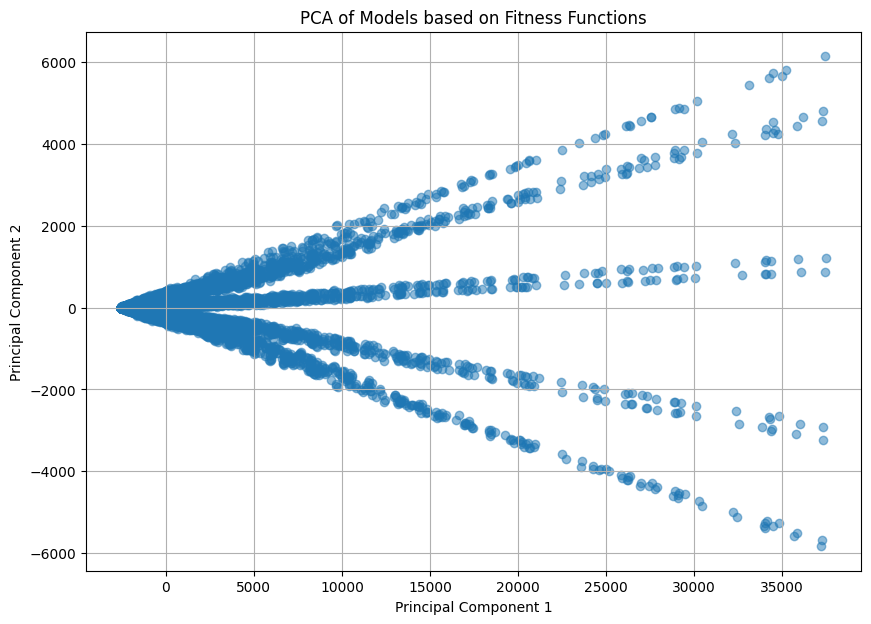

In [6]:
flatten_dataset = dataset.reshape(-1, dataset.shape[1])
print(f"Flattened dataset shape: {flatten_dataset.shape}")
def pca(X, num_components=2):
    # Center the data
    X_centered = X - np.mean(X)
    # Compute covariance matrix
    covariance_matrix = np.cov(X_centered, rowvar=False)
    # Eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
    # Sort eigenvalues and eigenvectors
    sorted_indices = np.argsort(eigenvalues)[::-1]
    sorted_eigenvalues = eigenvalues[sorted_indices]
    sorted_eigenvectors = eigenvectors[:, sorted_indices]
    # Select top components
    selected_eigenvectors = sorted_eigenvectors[:, :num_components]
    # Project data
    X_reduced = np.dot(X_centered, selected_eigenvectors)
    return X_reduced, sorted_eigenvalues[:num_components]


def plot_pca(components, labels=None):
    plt.figure(figsize=(10, 7))
    plt.scatter(components[:, 0], components[:, 1], alpha=0.5)
    plt.title('PCA of Models based on Fitness Functions')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.grid()
    plt.show()

components, _ = pca(flatten_dataset, num_components=2)
plot_pca(components)


## Variance analysis

### Same as before but instead of variance display the CV

In [5]:
std_vector = np.std(dataset, axis=1)
std_vector_normalized = std_vector / np.mean(dataset, axis=1)  # Variance across contexts for each function
std_vector_normalized = np.nan_to_num(std_vector_normalized, nan=0.0)
print(std_vector_normalized.shape)

(2122, 9)


/tmp/ipykernel_10196/181748876.py:2: RuntimeWarning: invalid value encountered in divide
  std_vector_normalized = std_vector / np.mean(dataset, axis=1)  # Variance across contexts for each function


Function: AliveCellsFitness, Top 5 variances: 1.673622189060436, 1.8701162621713332, 2.0447720191822576, 2.1538750413526353, 2.32161932260002


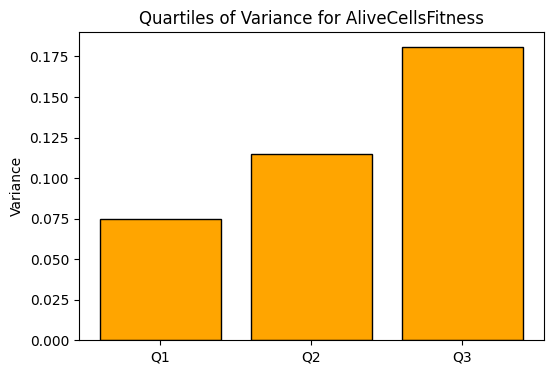

Function: CircularFitness, Top 5 variances: 2.32161932260002, 2.357924195479551, 3.379332080381518, 3.579266811737433, 3.69410757992951


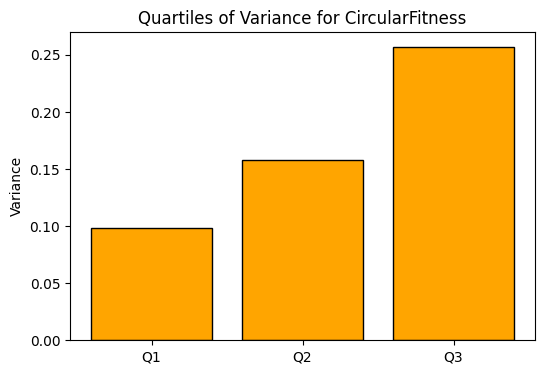

Function: CircularFitness_WT_DISTRIBUTION, Top 5 variances: 1.8701162621713332, 2.0447720191822576, 2.32161932260002, 5.665897197596929, 11.306973279788474


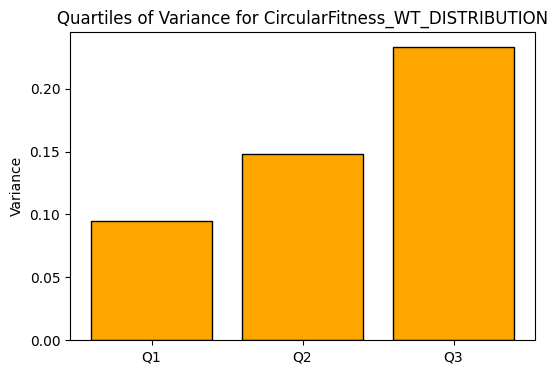

Function: SquaredFitness, Top 5 variances: 1.673622189060436, 1.8701162621713332, 2.0447720191822576, 2.1538750413526353, 2.32161932260002


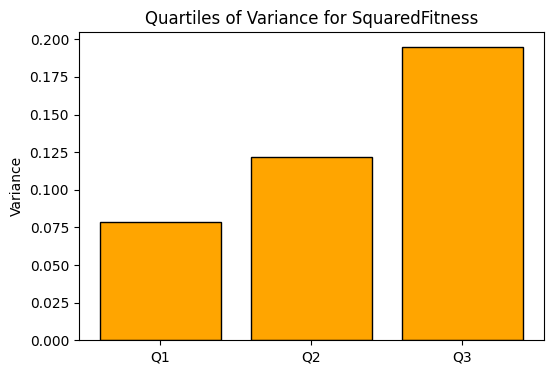

Function: SquaredFitness_WT_DISTRIBUTION, Top 5 variances: 1.673622189060436, 1.8701162621713332, 2.0447720191822576, 2.1538750413526353, 2.32161932260002


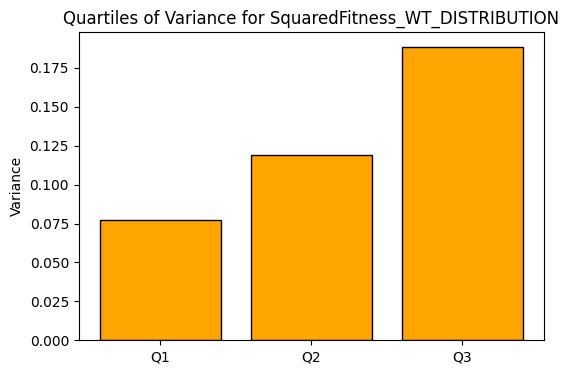

Function: CircularFitness_2, Top 5 variances: 1.8701162621713332, 1.943650631615101, 2.1538750413526353, 2.165264901351162, 2.2716557886050777


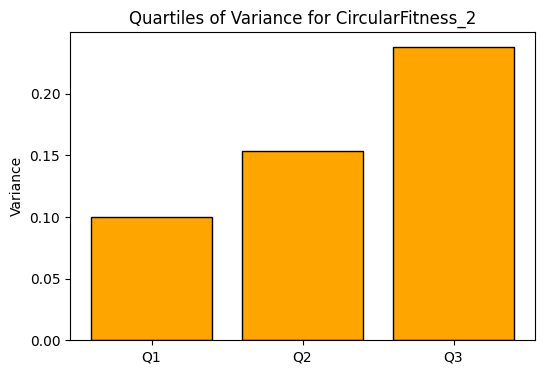

Function: CircularFitness_2_WT_DISTRIBUTION, Top 5 variances: 1.9304515025245126, 2.128942913238615, 2.1538750413526353, 2.20938939990047, 2.866983852490577


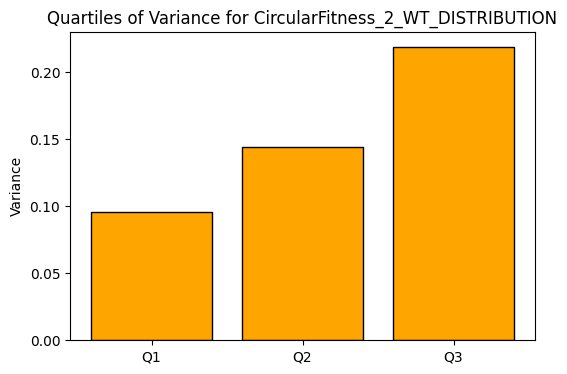

Function: SquaredFitness_2, Top 5 variances: 1.7334964465404907, 1.8701162621713332, 2.0447720191822576, 2.1538750413526353, 2.206523146713762


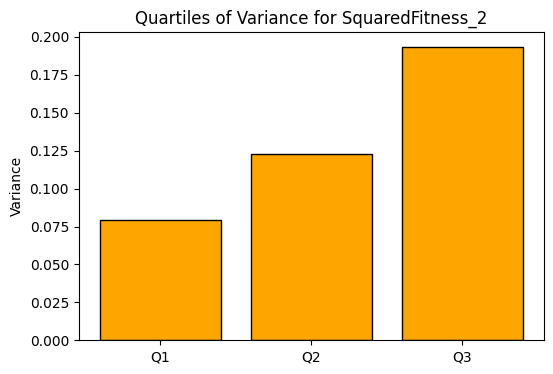

Function: SquaredFitness_2_WT_DISTRIBUTION, Top 5 variances: 1.673622189060436, 1.8701162621713332, 2.0447720191822576, 2.1538750413526353, 2.206410372292653


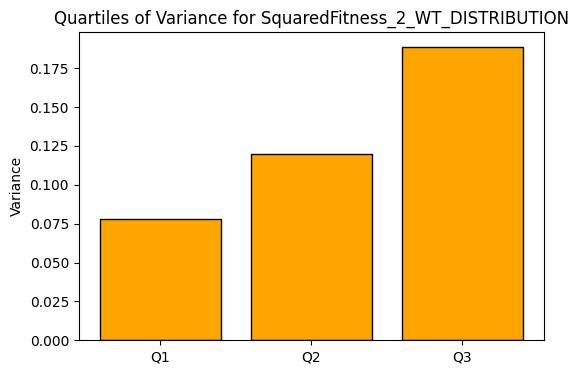

In [6]:
for i in range(dataset.shape[2]):
    best_indices = np.argsort(std_vector_normalized[:, i])[-5:]  # Indices of the 5 highest variances
    print(f"Function: {function_names[i]}, Top 5 variances: {", ".join([str(t) for t in std_vector_normalized[best_indices, i]])}")
    #Plot quartiles
    quartiles = np.percentile(std_vector_normalized[:, i], [25, 50, 75])
    plt.figure(figsize=(6, 4))
    plt.bar(['Q1', 'Q2', 'Q3'], quartiles, color='orange', edgecolor='black')
    plt.title(f"Quartiles of Variance for {function_names[i]}")
    plt.ylabel('Variance')
    plt.show()

### Display the distribution of standard deviation across models: for each bin representing an interval of st. dev., plot the number of models with this standard deviation.

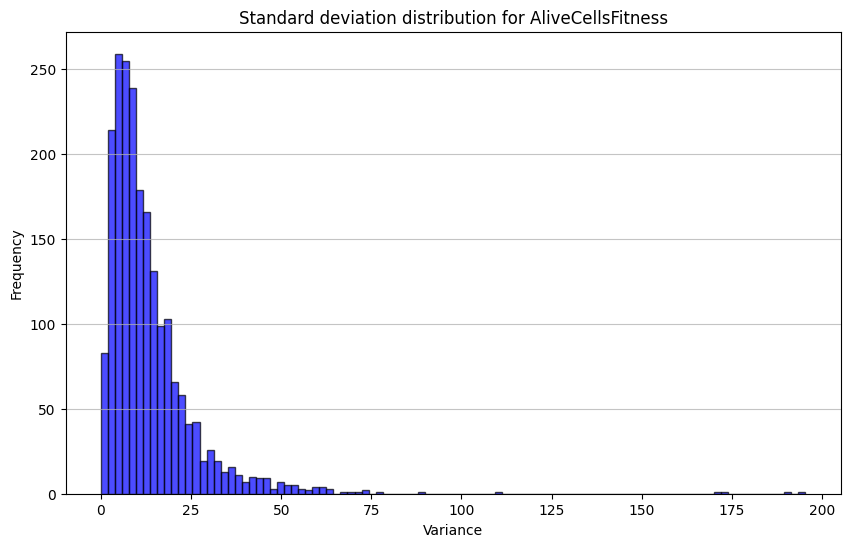

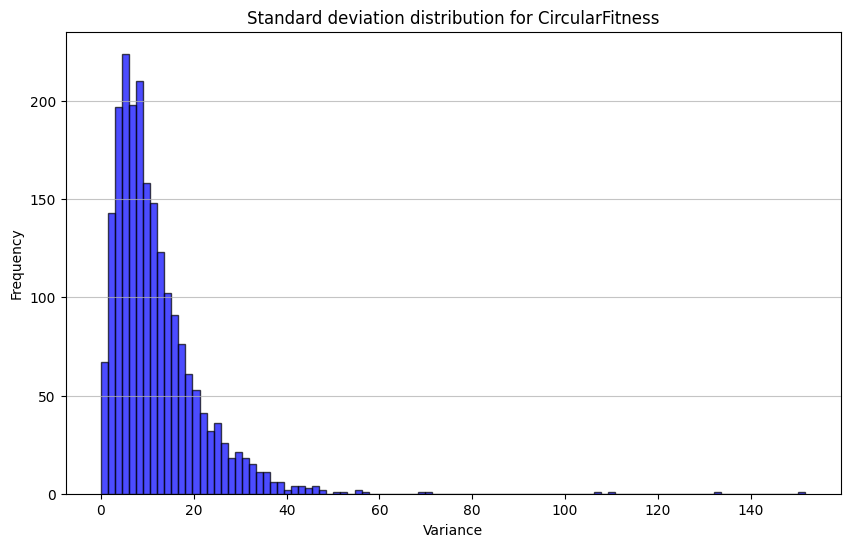

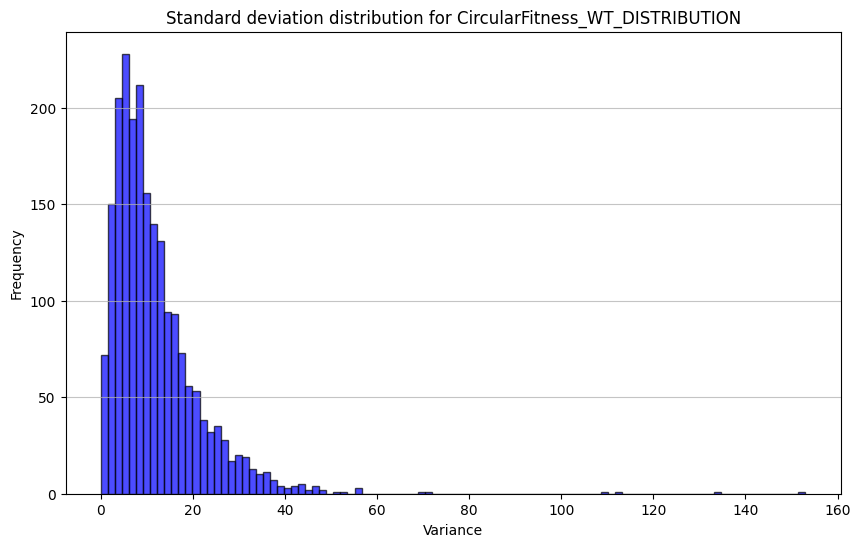

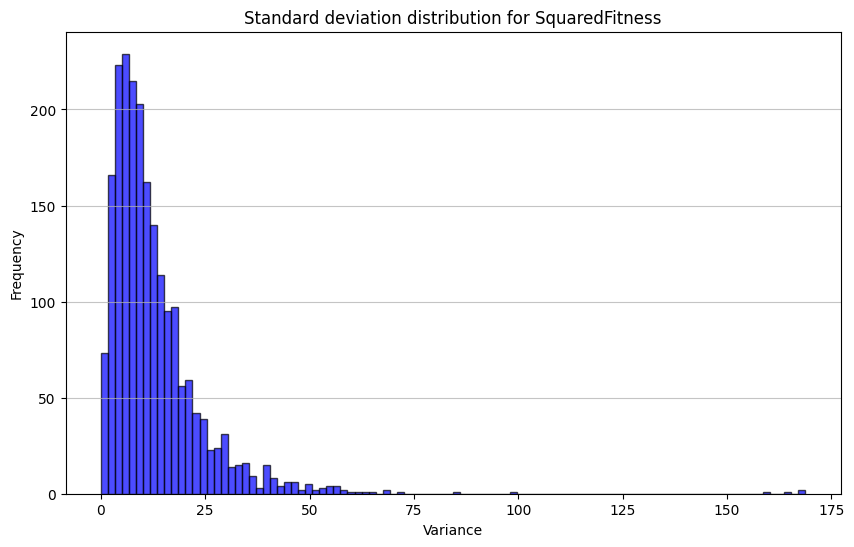

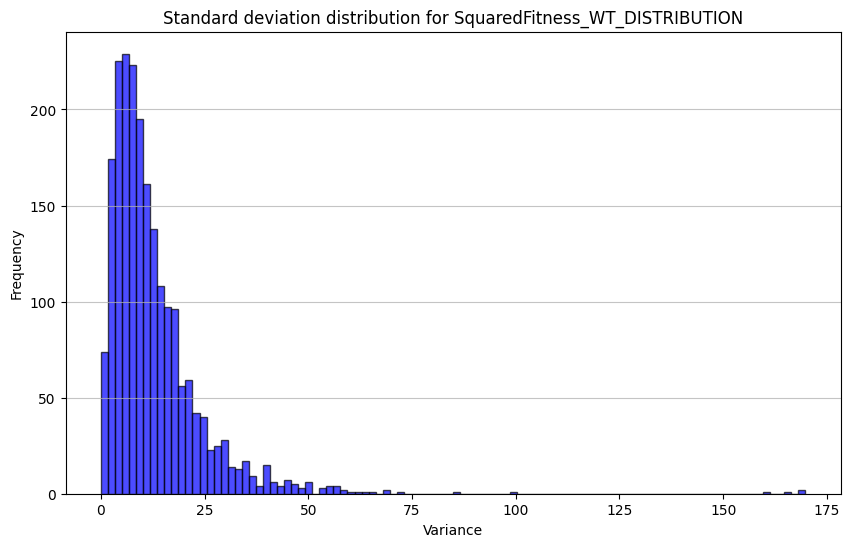

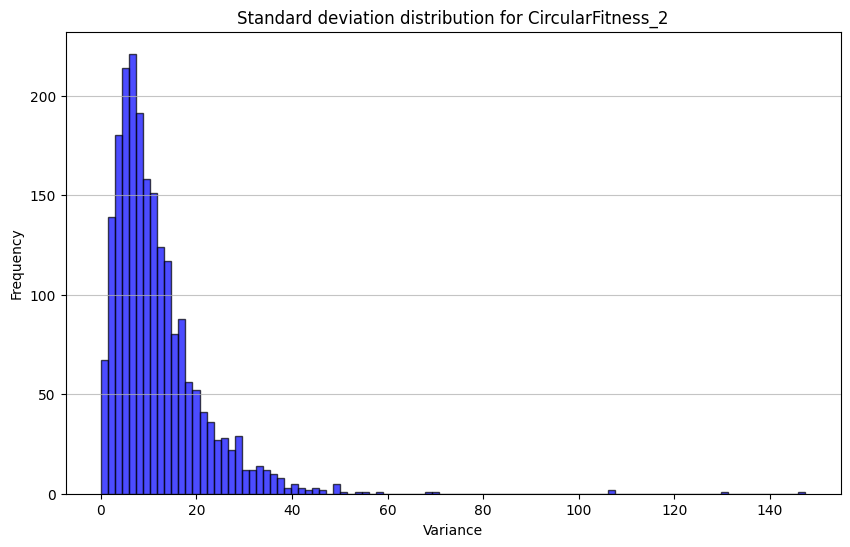

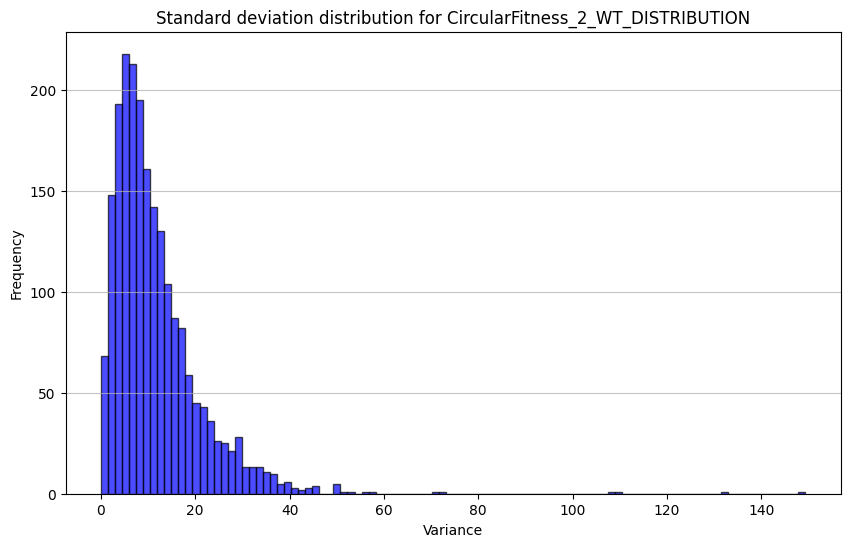

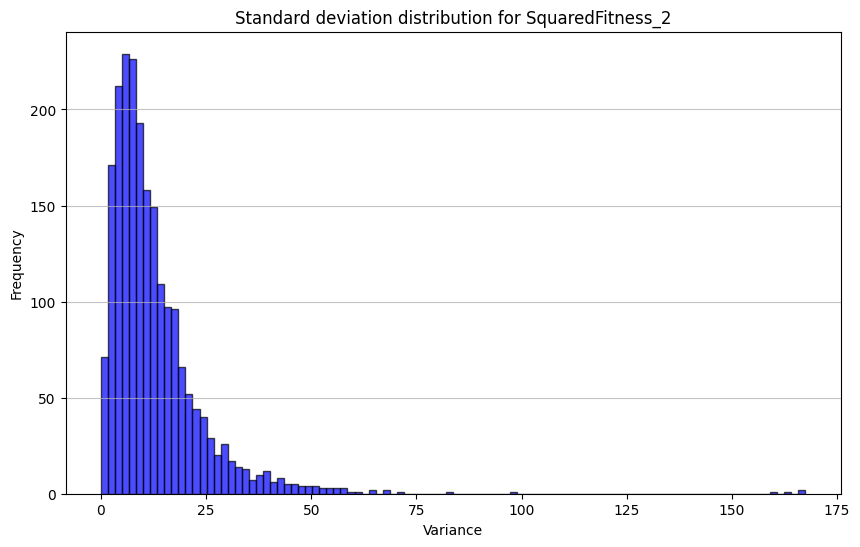

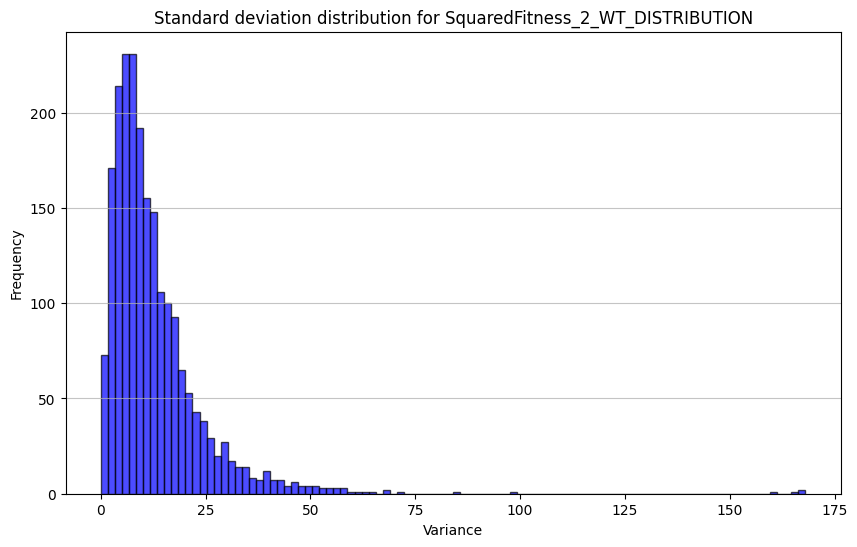

In [7]:

for i in range(len(function_names)):
    plt.figure(figsize=(10, 6))
    plt.hist(std_vector[:, i], bins=100, alpha=0.7, color='blue', edgecolor='black')
    plt.title(f"Standard deviation distribution for {function_names[i]}")
    plt.xlabel('Variance')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

## Filter models:

Two types of filters are supported:

1. Filter by Mean: keep only models that exhibit mean >= MEAN_THRESHOLD.
2. Filter by variance and CV, using two conditions in OR (keep models that respect at least one):
    * Standard deviation >= ABS_STD_THRESHOLD.
    * CV >= NORM_STD_THRESHOLD.

The parameters are defined at the head of this Notebook:

*MEAN_THRESHOLD = 0.0*

*ABS_STD_THRESHOLD = 30.0*

*NORM_STD_THRESHOLD = 0.2*

#### Prepare variables to filter the dataset while preserving information on the origin of each model

In [8]:
# Test- get rid of fitness functions != 0
#dataset = dataset[:,:,0]
dataset_by_f = [
    dataset[:,:,i:i+1] for i in range(dataset.shape[2])
]

In [ ]:
def filter_by_mean(threshold):
    mean_values = np.mean(flattened_ds[:, :], axis=1)
    mask = mean_values > threshold
    return mask

def filter_by_standard_deviation(threshold):
    std_vector = np.std(flattened_ds, axis=1)
    mask = std_vector > threshold
    return mask

def filter_by_standard_deviation_normalized(threshold):
    std_vector = np.std(flattened_ds, axis=1)
    std_vector_normalized = std_vector / np.mean(flattened_ds, axis=1)
    mask = std_vector_normalized > threshold
    return mask

filtered_indices_by_f = []
# Apply filters to each individual fitness function
for dataset in dataset_by_f:
    print("\nProcessing a single fitness function dataset")
    # Flatten the dataset to 2D: (num_models * num_fitness_functions, num_contexts)
    original_model_indexes = np.repeat(np.arange(dataset.shape[0]), dataset.shape[2])
    function_indexes = np.tile(np.arange(dataset.shape[2]), dataset.shape[0])
    flattened_ds = np.transpose(dataset, (0, 2, 1)).reshape(-1, dataset.shape[1])
    mean_mask = filter_by_mean(MEAN_THRESHOLD)
    std_mask = filter_by_standard_deviation(ABS_STD_THRESHOLD)
    std_norm_mask = filter_by_standard_deviation_normalized(NORM_STD_THRESHOLD)
    combined_mask = mean_mask & (std_mask | std_norm_mask)
    filtered_indices = np.where(combined_mask)[0]
    print(f"Number of models after filtering: {len(filtered_indices)} out of {flattened_ds.shape[0]}")
    print(f"The mean mask retains {np.sum(mean_mask)} models.")
    print(f"The absolute std mask retains {np.sum(std_mask)} models.")
    print(f"The normalized std mask retains {np.sum(std_norm_mask)} models.")
    print(f"The combined absolute and normalized std masks retains {np.sum(combined_mask)} models.")

    filtered_dataset = flattened_ds[filtered_indices, :]
    filtered_model_indexes = original_model_indexes[filtered_indices]
    filtered_function_indexes = function_indexes[filtered_indices]
    filtered_indices_by_f.append(filtered_indices)
    print(f"Filtered dataset shape: {filtered_dataset.shape}")


# Find models that satisfy the filter for the alive cells count
filtered_indices_by_f = [
    set(indices) for indices in filtered_indices_by_f
]
all_indices = set(filtered_indices_by_f[0])
#set.intersection(*filtered_indices_by_f)
flattened_ds = np.transpose(dataset, (0, 2, 1)).reshape(-1, dataset.shape[1])
print(f"\nNumber of models satisfying all fitness functions: {len(all_indices)} out of {flattened_ds.shape[0]}")
filtered_dataset = flattened_ds[list(all_indices), :]
filtered_function_indexes = function_indexes[list(all_indices)]



Processing a single fitness function dataset
Number of models after filtering: 612 out of 2122
The mean mask retains 2111 models.
The absolute std mask retains 161 models.
The normalized std mask retains 461 models.
The combined absolute and normalized std masks retains 612 models.
Filtered dataset shape: (612, 215)

Processing a single fitness function dataset
Number of models after filtering: 877 out of 2122
The mean mask retains 2108 models.
The absolute std mask retains 102 models.
The normalized std mask retains 782 models.
The combined absolute and normalized std masks retains 877 models.
Filtered dataset shape: (877, 215)

Processing a single fitness function dataset
Number of models after filtering: 779 out of 2122
The mean mask retains 2111 models.
The absolute std mask retains 102 models.
The normalized std mask retains 685 models.
The combined absolute and normalized std masks retains 779 models.
Filtered dataset shape: (779, 215)

Processing a single fitness function datas

/tmp/ipykernel_10196/1060434633.py:13: RuntimeWarning: invalid value encountered in divide
  std_vector_normalized = std_vector / np.mean(flattened_ds, axis=1)


In [38]:
# Export filtered dataset to final_pool
all_indices = np.array(list(all_indices))
import csv
all_description = []
with open(os.path.join('subjects.csv'), 'r') as f:
    row = csv.reader(f)
    for row in f:
        row = row.strip().split(',')
        family, model = row[8], row[9]
        all_description.append((family, model))
all_description = np.array(all_description)
final = all_description[all_indices]
print(all_indices.shape, all_description.shape, final.shape)
with open(os.path.join(output_dir, 'final_pool.csv'), 'w') as f:
    for entry in final:
        f.write(f"{entry[0]},{entry[1]}\n")

(637,) (2122, 2) (637, 2)


### Further analysis

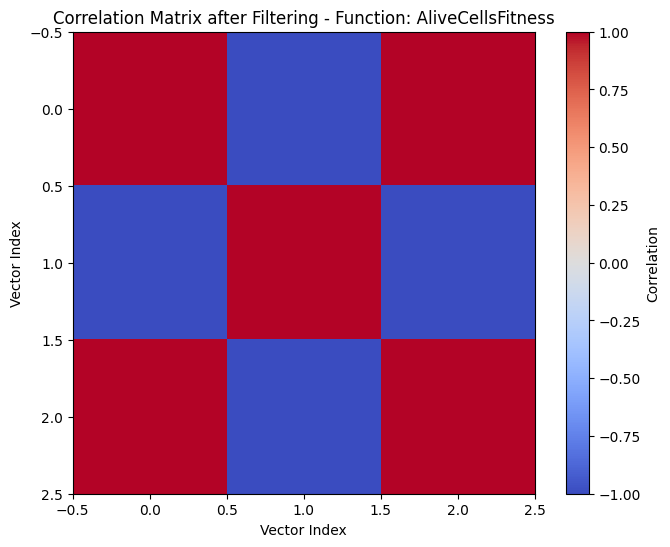

Avg abs correlation: 0.6641364571522959, max abs correlation: 0.999997350901212


In [17]:
correlation_matrix = np.corrcoef(filtered_dataset)
# Method 1: Using matplotlib
plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.title(f"Correlation Matrix after Filtering - Function: {function_names[0]}")
plt.xlabel('Vector Index')
plt.ylabel('Vector Index')
plt.show()
# Max correlation
correlation_matrix_no_diagonal = correlation_matrix.copy()
np.fill_diagonal(correlation_matrix_no_diagonal, 0) # Ignore self-correlation
max_abs_correlation = np.max(np.abs(correlation_matrix_no_diagonal))
avg_abc_correlation = np.mean(np.abs(correlation_matrix_no_diagonal))
print(f"Avg abs correlation: {avg_abc_correlation}, max abs correlation: {max_abs_correlation}")


## Label models in filtered_dataset by the existence of outliers
Each model is scored by the number of outliers it exhibited and their strength.

In [18]:
import numpy as np

outlier_strength_scores = []

for values in filtered_dataset:
    values = np.asarray(values)
    median = np.median(values)
    mad = np.median(np.abs(values - median))

    if mad == 0:
        outlier_strength_scores.append(0)
        continue

    modified_z = 0.6745 * (values - median) / mad
    abs_mz = np.abs(modified_z)

    threshold = 3.5
    outliers = abs_mz > threshold

    # Outlier strength = how far points exceed typical outlier threshold
    strength = np.sum(abs_mz[outliers] - threshold)
    outlier_strength_scores.append(strength)


print(f"Outlier strength scores:", "\n".join([f"\t{i}: {score}" for i, score in enumerate(outlier_strength_scores)]))
print(f"Max outlier strength score: {max(outlier_strength_scores)}")
outlier_strength_scores = np.array(outlier_strength_scores)
print(f"Average and quartiles of outlier strength scores:", np.mean(outlier_strength_scores), np.percentile(outlier_strength_scores, [25, 50, 75]))

Outlier strength scores: 	0: 1.6616164914629934
	1: 2379.4890129652235
	2: 1.5436762312467094
Max outlier strength score: 2379.4890129652235
Average and quartiles of outlier strength scores: 794.231435229311 [   1.60264636    1.66161649 1190.57531473]


## Copy the models that survived the filtering and write manifest

In [39]:
# Final: FAMILY,MODEL
# original model path: {mutated_boolean_models_dir}/{family}/{model}.bnd and .cfg
# output model path: {output_models_dir}/{family}/{model}.bnd and .cfg
generated = []
for entry in final:
    family, model = entry
    generated.append({
        "family": family,
        "V": model,
        "ID": len(generated)
    })
    original_bnd_path = os.path.join(mutated_boolean_models_dir, family, f"{model}.bnd")
    original_cfg_path = os.path.join(mutated_boolean_models_dir, family, f"{model}.cfg")
    output_family_dir = os.path.join(output_models_dir, family)
    output_bnd_path = os.path.join(output_models_dir, family, f"{model}.bnd")
    output_cfg_path = os.path.join(output_models_dir, family, f"{model}.cfg")
    os.makedirs(output_family_dir, exist_ok=True)
    if os.path.exists(original_bnd_path) and os.path.exists(original_cfg_path):
        os.system(f"cp {original_bnd_path} {output_bnd_path}")
        os.system(f"cp {original_cfg_path} {output_cfg_path}")
    else:
        print(f"Warning: Original model files not found for {family}/{model}, skipping copy.")

import json 
with open(os.path.join(output_models_dir, 'manifest.json'), 'w') as f:
    json.dump(generated, f, indent=4)

# 